# DLS vs NN — sanity check

Compare the NN win-prob model against a Duckworth–Lewis–Stern style *resource* model on the same match states.

Notes:
- DLS is designed for *revised targets* under interruptions, not directly a win-prob model.
- Here we convert DLS resources into a win-prob proxy and calibrate it to match the empirical win-prob targets.

In [2]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

MODELS_DIR = Path('../models')
DATA_DIR   = Path('../data/raw')
DLS_CSV    = Path('../data/dls/dls_resource_data_for_t20s.csv')
FIG_DIR    = Path('../data/figures/05_dls_comparison')
FIG_DIR.mkdir(parents=True, exist_ok=True)

MATCH_FILES = [
    DATA_DIR / 'dc_vs_gt_2026-04-08.json',
    DATA_DIR / 'ind_vs_pak_2024-06-09.json',
    DATA_DIR / 'rr_vs_mi_2026-04-07.json',
    DATA_DIR / 'mi_vs_rr_2025-05-01.json',
]

FEATURE_COLS = ['runs_needed', 'balls_remaining', 'wickets_fallen', 'rrr', 'balls_fraction', 'wickets_fraction']

In [3]:
class WinProbNet(nn.Module):
    def __init__(self, input_dim=6, hidden_dims=[64, 32, 16]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def load_nn():
    ckpt = torch.load(MODELS_DIR / 'win_prob_nn.pt', weights_only=False)
    model = WinProbNet(input_dim=ckpt['input_dim'], hidden_dims=ckpt['hidden_dims'])
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt


model, nn_ckpt = load_nn()
X_mean = np.array(nn_ckpt['X_mean'], dtype=np.float32)
X_std  = np.array(nn_ckpt['X_std'], dtype=np.float32)

with open(MODELS_DIR / 'emp_lookup.pkl', 'rb') as f:
    emp_lookup = pickle.load(f)

print('Loaded NN checkpoint keys:', list(nn_ckpt.keys()))
print('Loaded empirical lookup entries:', len(emp_lookup))

Loaded NN checkpoint keys: ['input_dim', 'hidden_dims', 'model_state_dict', 'feature_cols', 'X_mean', 'X_std']
Loaded empirical lookup entries: 2112


In [4]:
def parse_chase(path: Path):
    d = json.load(open(path))
    inn1, inn2 = d['innings'][0], d['innings'][1]

    target = sum(b['runs']['total'] for ov in inn1['overs'] for b in ov['deliveries']) + 1
    total_balls = sum(
        1 for ov in inn1['overs'] for b in ov['deliveries']
        if 'wides' not in b.get('extras', {}) and 'noballs' not in b.get('extras', {})
    )

    rows, score, wickets, legal_ball = [], 0, 0, 0
    for ov in inn2['overs']:
        for b in ov['deliveries']:
            ext = list(b.get('extras', {}).keys())
            is_legal = 'wides' not in ext and 'noballs' not in ext
            score += b['runs']['total']
            if 'wickets' in b:
                wickets += len(b['wickets'])
            if is_legal:
                legal_ball += 1
                rn = target - score
                br = total_balls - legal_ball
                rows.append({
                    'match': path.stem,
                    'legal_ball': legal_ball,
                    'target': target,
                    'first_innings': target - 1,
                    'score': score,
                    'runs_needed': rn,
                    'balls_remaining': br,
                    'wickets_fallen': wickets,
                })

    df = pd.DataFrame(rows)

    # Clamp to valid chase states (avoid negative balls_remaining when inn1 ended early)
    df = df[(df['balls_remaining'] >= 0) & (df['balls_remaining'] <= 120)].copy()
    df['runs_needed'] = df['runs_needed'].clip(lower=0)
    return df


def build_features(df: pd.DataFrame) -> np.ndarray:
    feat = df[['runs_needed', 'balls_remaining', 'wickets_fallen']].copy()
    feat['rrr'] = feat['runs_needed'] / (feat['balls_remaining'] + 1)
    feat['balls_fraction'] = feat['balls_remaining'] / 120
    feat['wickets_fraction'] = feat['wickets_fallen'] / 10
    return feat[FEATURE_COLS].values.astype(np.float32)


def nn_predict_batch(df: pd.DataFrame) -> np.ndarray:
    X_raw = build_features(df)
    X_n = (X_raw - X_mean) / X_std
    X_t = torch.tensor(np.nan_to_num(X_n, nan=0.0, posinf=0.0, neginf=0.0))
    with torch.no_grad():
        return model(X_t).detach().cpu().numpy()


def empirical_win_prob(rn, br, wk) -> float:
    key = (int((rn // 5) * 5), int((br // 6) * 6), int(min(wk, 9)))
    if key in emp_lookup:
        return float(emp_lookup[key])
    for off in [1, -1, 2, -2]:
        k2 = (key[0], key[1], max(0, min(9, key[2] + off)))
        if k2 in emp_lookup:
            return float(emp_lookup[k2])
    return float('nan')


def add_empirical(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['p_emp'] = df.apply(lambda r: empirical_win_prob(r['runs_needed'], r['balls_remaining'], r['wickets_fallen']), axis=1)
    return df

In [5]:
dls_table = pd.read_csv(DLS_CSV)
# Columns 0..9 are wickets_lost in the table (cap at 9).
WICKET_COLS = [str(i) for i in range(10)]


def dls_resource_pct(balls_remaining: float, wickets_fallen: int) -> float:
    """Return DLS resource % remaining for a T20 state.

    Uses linear interpolation on balls, and the 'wickets lost' column equal to wickets_fallen (capped at 9).
    """
    br = float(np.clip(balls_remaining, 0, 120))
    wl = int(np.clip(wickets_fallen, 0, 9))

    # exact match on row
    if br in set(dls_table['balls'].values):
        row = dls_table.loc[dls_table['balls'] == br].iloc[0]
        return float(row[str(wl)])

    # interpolate between nearest rows
    balls = dls_table['balls'].values
    lo = balls[balls <= br].max(initial=0)
    hi = balls[balls >= br].min(initial=120)

    if lo == hi:
        row = dls_table.loc[dls_table['balls'] == lo].iloc[0]
        return float(row[str(wl)])

    row_lo = dls_table.loc[dls_table['balls'] == lo].iloc[0]
    row_hi = dls_table.loc[dls_table['balls'] == hi].iloc[0]
    v_lo = float(row_lo[str(wl)])
    v_hi = float(row_hi[str(wl)])

    t = (br - lo) / (hi - lo)
    return (1 - t) * v_lo + t * v_hi


def dls_win_proxy(df: pd.DataFrame, k: float) -> np.ndarray:
    """Convert DLS resources into a win-prob proxy.

    We treat (first_innings * resources_remaining%) as an estimate of achievable runs remaining.
    Margin > 0 => above-par position. k controls slope of sigmoid.
    """
    res = df.apply(lambda r: dls_resource_pct(r['balls_remaining'], r['wickets_fallen']), axis=1).values / 100.0
    achievable = df['first_innings'].values * res
    margin = achievable - df['runs_needed'].values
    return 1.0 / (1.0 + np.exp(-k * margin))


print('Loaded DLS table rows:', len(dls_table))

Loaded DLS table rows: 21


In [6]:
# Build a dataset of ball-states across matches
rows = []
for p in MATCH_FILES:
    chase = parse_chase(p)
    chase = add_empirical(chase)
    chase['p_nn'] = nn_predict_batch(chase)
    rows.append(chase)

states = pd.concat(rows, ignore_index=True)
# Keep only rows where empirical target is defined (this is our "label")
states = states.dropna(subset=['p_emp']).copy()

print('Total states:', len(states))
print(states[['match','legal_ball','runs_needed','balls_remaining','wickets_fallen','p_emp','p_nn']].head())

Total states: 383
                 match  legal_ball  runs_needed  balls_remaining  \
0  dc_vs_gt_2026-04-08           1          211              119   
1  dc_vs_gt_2026-04-08           2          207              118   
2  dc_vs_gt_2026-04-08           3          203              117   
3  dc_vs_gt_2026-04-08           4          202              116   
4  dc_vs_gt_2026-04-08           5          201              115   

   wickets_fallen     p_emp      p_nn  
0               0  0.224138  0.256832  
1               0  0.226994  0.284569  
2               0  0.337931  0.318651  
3               0  0.337931  0.322194  
4               0  0.337931  0.324691  


In [7]:
# Calibrate the DLS proxy slope k to best match empirical probabilities
ks = np.linspace(0.01, 0.30, 120)
mses = []
for k in ks:
    p = dls_win_proxy(states, k)
    mses.append(np.mean((p - states['p_emp'].values) ** 2))

best_k = float(ks[int(np.argmin(mses))])
print('Best k:', best_k, 'MSE:', float(np.min(mses)))

states['p_dls'] = dls_win_proxy(states, best_k)

# Simple metrics vs empirical
mae_nn  = float(np.mean(np.abs(states['p_nn'].values  - states['p_emp'].values)))
mae_dls = float(np.mean(np.abs(states['p_dls'].values - states['p_emp'].values)))

print('MAE vs empirical  |  NN:', round(mae_nn, 4), ' DLS-proxy:', round(mae_dls, 4))

Best k: 0.056302521008403356 MSE: 0.06677945458745185
MAE vs empirical  |  NN: 0.0507  DLS-proxy: 0.2109


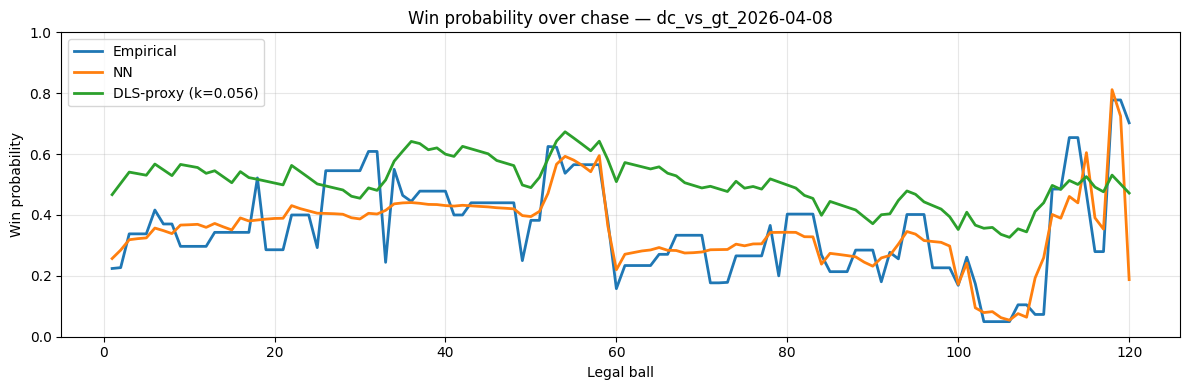

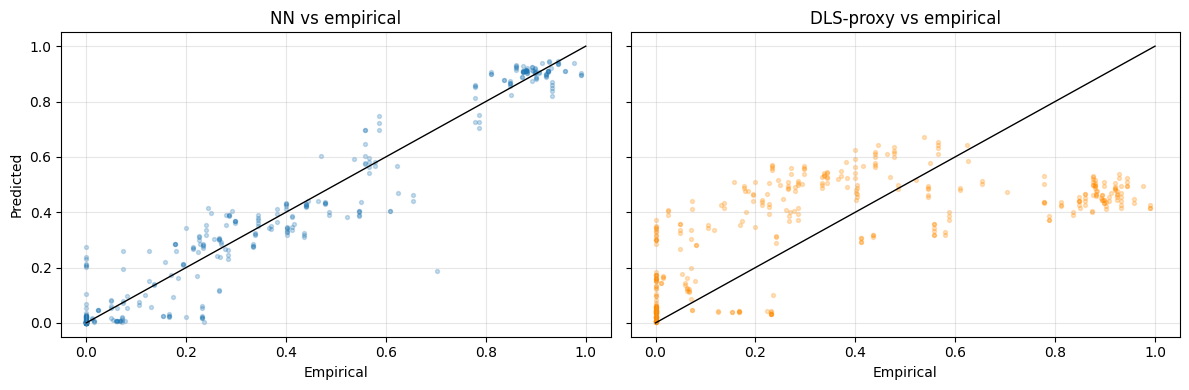

In [8]:
# Visual comparison on one match: curves over the chase
match_name = 'dc_vs_gt_2026-04-08'
ex = states[states['match'] == match_name].sort_values('legal_ball').copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ex['legal_ball'], ex['p_emp'], label='Empirical', linewidth=2)
ax.plot(ex['legal_ball'], ex['p_nn'],  label='NN', linewidth=2)
ax.plot(ex['legal_ball'], ex['p_dls'], label=f'DLS-proxy (k={best_k:.3f})', linewidth=2)
ax.set_title(f'Win probability over chase — {match_name}')
ax.set_xlabel('Legal ball')
ax.set_ylabel('Win probability')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f'winprob_overlay_{match_name}.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter: DLS vs empirical, NN vs empirical
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].scatter(states['p_emp'], states['p_nn'], s=8, alpha=0.25)
axes[0].plot([0,1],[0,1], color='black', linewidth=1)
axes[0].set_title('NN vs empirical')
axes[0].set_xlabel('Empirical')
axes[0].set_ylabel('Predicted')

axes[1].scatter(states['p_emp'], states['p_dls'], s=8, alpha=0.25, color='darkorange')
axes[1].plot([0,1],[0,1], color='black', linewidth=1)
axes[1].set_title('DLS-proxy vs empirical')
axes[1].set_xlabel('Empirical')

plt.tight_layout()
plt.savefig(FIG_DIR / 'scatter_vs_empirical.png', dpi=150, bbox_inches='tight')
plt.show()

## NN vs DLS — direct comparison

Now that both models are calibrated/available on the same ball-states, we can compare them directly:
- Where do they agree/disagree?
- Are disagreements concentrated in late-innings / high-wicket states?
- Is one systematically more optimistic than the other?

NN vs DLS-proxy
  MAE : 0.2071
  RMSE: 0.2565
  Bias (NN - DLS): 0.0216
  Corr: 0.6695


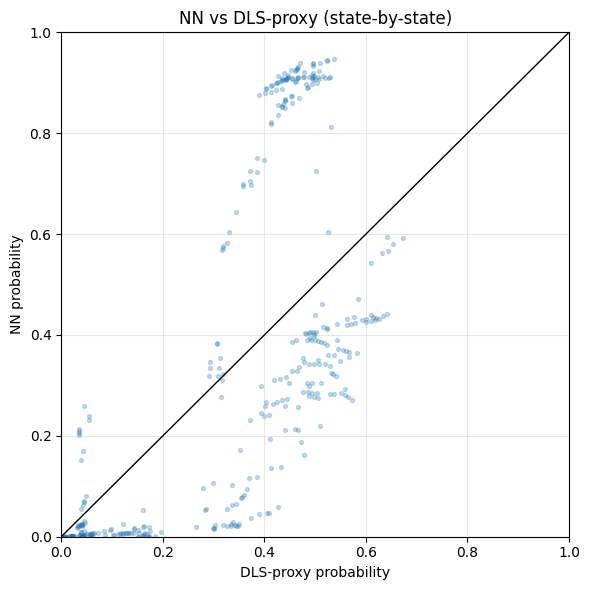

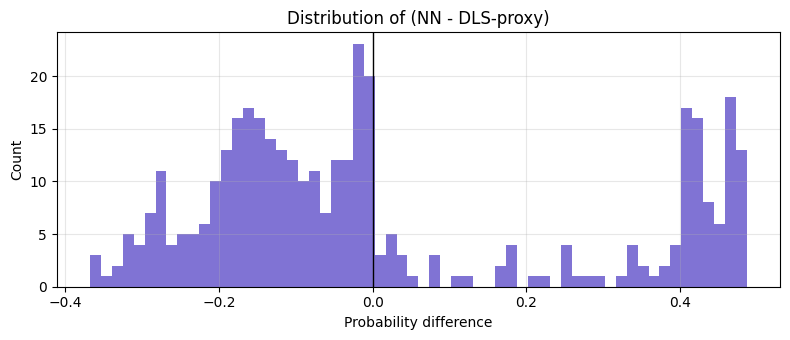

In [9]:
# Requires: states dataframe with p_nn and p_dls already computed
req_cols = {'p_nn', 'p_dls', 'p_emp', 'balls_remaining', 'wickets_fallen', 'runs_needed', 'match'}
missing = req_cols - set(states.columns)
assert not missing, f"Missing columns in states: {missing}"

states2 = states.copy()
states2['diff_nn_minus_dls'] = states2['p_nn'] - states2['p_dls']

# Summary stats
mae_nn_dls = float(np.mean(np.abs(states2['diff_nn_minus_dls'])))
mean_bias  = float(np.mean(states2['diff_nn_minus_dls']))
rmse       = float(np.sqrt(np.mean(states2['diff_nn_minus_dls'] ** 2)))

corr = float(np.corrcoef(states2['p_nn'].values, states2['p_dls'].values)[0, 1])

print('NN vs DLS-proxy')
print('  MAE :', round(mae_nn_dls, 4))
print('  RMSE:', round(rmse, 4))
print('  Bias (NN - DLS):', round(mean_bias, 4))
print('  Corr:', round(corr, 4))

# Scatter: NN vs DLS
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(states2['p_dls'], states2['p_nn'], s=8, alpha=0.25)
ax.plot([0, 1], [0, 1], color='black', linewidth=1)
ax.set_title('NN vs DLS-proxy (state-by-state)')
ax.set_xlabel('DLS-proxy probability')
ax.set_ylabel('NN probability')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'scatter_nn_vs_dls.png', dpi=150, bbox_inches='tight')
plt.show()

# Histogram of differences
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(states2['diff_nn_minus_dls'], bins=60, color='slateblue', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Distribution of (NN - DLS-proxy)')
ax.set_xlabel('Probability difference')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hist_nn_minus_dls.png', dpi=150, bbox_inches='tight')
plt.show()

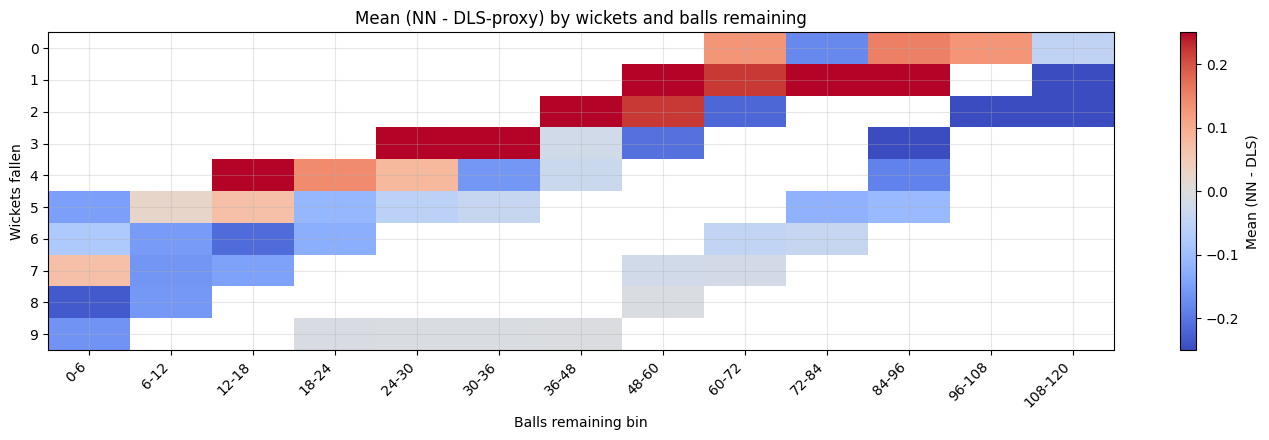

Top disagreements (absolute):
                match  legal_ball  runs_needed  balls_remaining  wickets_fallen    p_emp     p_nn    p_dls  diff_nn_minus_dls
ind_vs_pak_2024-06-09          32           94               82               1 0.835821 0.876475 0.389225           0.487250
ind_vs_pak_2024-06-09          59           67               55               1 0.859649 0.912783 0.426515           0.486268
ind_vs_pak_2024-06-09          50           77               64               1 0.873016 0.889274 0.403422           0.485852
ind_vs_pak_2024-06-09          49           78               65               1 0.873016 0.887984 0.402234           0.485749
ind_vs_pak_2024-06-09          48           78               66               1 0.989796 0.895780 0.414645           0.481135
ind_vs_pak_2024-06-09          47           79               67               1 0.989796 0.894497 0.413447           0.481050
ind_vs_pak_2024-06-09          58           67               56               1 0.859649

In [10]:
# Where do they disagree? (by wickets and balls remaining)
# Bin balls_remaining into coarse buckets for a stable view.
bins = [0, 6, 12, 18, 24, 30, 36, 48, 60, 72, 84, 96, 108, 120]
labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

states2['br_bin'] = pd.cut(states2['balls_remaining'], bins=bins, labels=labels, include_lowest=True)
states2['wk'] = states2['wickets_fallen'].clip(0, 9).astype(int)

pivot = (
    states2
    .groupby(['wk', 'br_bin'], observed=True)['diff_nn_minus_dls']
    .mean()
    .unstack('br_bin')
    .sort_index(ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 4.5))
im = ax.imshow(pivot.values, aspect='auto', cmap='coolwarm', vmin=-0.25, vmax=0.25)
ax.set_title('Mean (NN - DLS-proxy) by wickets and balls remaining')
ax.set_xlabel('Balls remaining bin')
ax.set_ylabel('Wickets fallen')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label='Mean (NN - DLS)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'heatmap_nn_minus_dls_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

# Show the most extreme disagreements
show_n = 12
extreme = states2.reindex(states2['diff_nn_minus_dls'].abs().sort_values(ascending=False).index)
cols = ['match', 'legal_ball', 'runs_needed', 'balls_remaining', 'wickets_fallen', 'p_emp', 'p_nn', 'p_dls', 'diff_nn_minus_dls']
print('Top disagreements (absolute):')
print(extreme[cols].head(show_n).to_string(index=False))